# ✋ Hand Pose Estimation — YOLOv12s Training Pipeline
## CSE 445 — Computer Vision | Assignment 2

**Course:** CSE 445 — Computer Vision  
**Assignment:** 2 — Pose Estimation and Object Tracking  
**Platform:** Kaggle (CUDA GPU — T4 / P100)  
**Model:** YOLOv12s-Pose (trained from scratch)  
**Dataset:** Hand Keypoint Detection v8 (Roboflow — 21 keypoints per hand)  

---

## 📌 Pipeline Overview

| Step | Description |
|------|-------------|
| **1** | Environment setup & version verification |
| **2** | Dataset inspection & exploratory analysis |
| **3** | Dataset preparation (90/10 train/val split & YAML config) |
| **4** | Dataset visualization (images + keypoint annotations) |
| **5** | YOLOv12s-Pose model training (CUDA-accelerated) |
| **6** | Explicit model evaluation (`model.val()`) & training metrics |
| **7** | Pose estimation inference on held-out validation images |
| **8** | Export trained weights for video tracking notebook |

---

## 🔬 Model Selection Justification — YOLOv12s vs YOLOv26s

**YOLOv12s** was selected over YOLOv26s for the following technical reasons:

1. **Attention-Centric Architecture:** YOLOv12 introduces **A2C2f (Area Attention)** blocks — a linear-complexity attention mechanism that captures global context. This is critical for hand pose estimation where occluded fingers require understanding of the entire hand region, not just local patches.
2. **Parameter Efficiency:** The 's' variant (~9.8M params, ~23.5 GFLOPs) provides a strong capacity-to-speed tradeoff, fitting within Kaggle's T4 GPU (16GB VRAM) at batch size 16.
3. **Dedicated Pose Head:** `yolo12s-pose.yaml` includes a Pose detection head supporting arbitrary `kpt_shape`, enabling direct use with the 21-keypoint hand format.
4. **Stronger than YOLOv8s-pose on detection tasks** due to the attention mechanism, while remaining computationally comparable.

---

## 📂 Kaggle Dataset Instructions

Upload the `Hand.v8i.yolov8` folder to Kaggle as a dataset named `hand-v8i-yolov8`.  
The dataset will be available at: `/kaggle/input/hand-v8i-yolov8/`

> **GPU Accelerator must be ON** — go to Settings → Accelerator → GPU T4 x2 or P100

---

## 📦 Step 1 — Environment Setup & Version Verification

In [1]:
# =============================================================================
# Install / upgrade required packages
# ultralytics >= 8.3 includes YOLO12 architecture support
# lapx         required by ByteTrack's C++ association extension
# =============================================================================
!pip install -q ultralytics lapx

import ultralytics
ultralytics.checks()  # Prints YOLO version, CUDA status, and environment info

import torch
import platform
import sys
import os

# ── Device selection — Kaggle provides CUDA ─────────────────────
if torch.cuda.is_available():
    DEVICE = "0"  # First CUDA GPU
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
else:
    DEVICE = "cpu"
    gpu_name = "N/A"
    gpu_mem  = 0

print(f"\n{'='*60}")
print(f"  Python:        {sys.version.split()[0]}")
print(f"  Ultralytics:   {ultralytics.__version__}")
print(f"  PyTorch:       {torch.__version__}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
print(f"  CUDA Version:  {torch.version.cuda}")
print(f"  GPU Name:      {gpu_name}")
print(f"  GPU Memory:    {gpu_mem:.1f} GB")
print(f"  Selected Device: {DEVICE}")
print(f"  Platform:      {platform.platform()}")
print(f"{'='*60}")

if DEVICE == "cpu":
    print("\n⚠️ CUDA not available. Enable GPU in Kaggle Settings → Accelerator.")
else:
    print(f"\n✅ CUDA GPU ready: {gpu_name} ({gpu_mem:.1f} GB)")

# ── Kaggle paths ────────────────────────────────────────────────
# Dataset mounted at /kaggle/input/<dataset-name>/
# All outputs go to /kaggle/working/ (persists between cells)
KAGGLE_INPUT  = "/kaggle/input"
KAGGLE_OUTPUT = "/kaggle/working"
print(f"\n  Input dir:  {KAGGLE_INPUT}")
print(f"  Output dir: {KAGGLE_OUTPUT}")
print(f"  Input contents: {os.listdir(KAGGLE_INPUT)}")

Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)

  Python:        3.12.12
  Ultralytics:   8.4.38
  PyTorch:       2.10.0+cu128
  CUDA Available: True
  CUDA Version:  12.8
  GPU Name:      Tesla T4
  GPU Memory:    15.6 GB
  Selected Device: 0
  Platform:      Linux-6.6.113+-x86_64-with-glibc2.35

✅ CUDA GPU ready: Tesla T4 (15.6 GB)

  Input dir:  /kaggle/input
  Output dir: /kaggle/working
  Input contents: ['datasets']


## 📂 Step 2 — Dataset Inspection & Exploratory Analysis

**Dataset:** Hand Keypoint Detection v8  
**Source:** [Roboflow Universe — hand-64xkf/8](https://universe.roboflow.com/handkeypoints/hand-64xkf/dataset/8)  
**License:** CC BY 4.0  
**Format:** YOLOv8-Pose  
**Pre-processing:** Auto-orientation + Resize to 640×640 (stretch)  

### Dataset Characteristics
| Property | Value |
|----------|-------|
| Total images | 2504 |
| Classes | 1 (hand) |
| Keypoints per hand | 21 |
| Keypoint dimensions | 3 (x, y, visibility) |
| Visibility encoding | 0 = unlabeled, 1 = occluded, 2 = visible |
| Label format | `<cls> <cx> <cy> <w> <h> <kp1_x> <kp1_y> <kp1_v> ...` |

In [2]:
import glob
import yaml
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

# ── Locate dataset — Kaggle mounts under /kaggle/input/ ─────────
# Update DATASET_SLUG if you named it differently when uploading
DATASET_SLUG = "datasets/turjo410/handposition/Hand.v8i.yolov8"   # ← name used when uploading to Kaggle
DATASET_ROOT = f"/kaggle/input/{DATASET_SLUG}"

if not os.path.exists(DATASET_ROOT):
    # Fallback: search for any hand dataset in input
    candidates = [d for d in os.listdir(KAGGLE_INPUT) if "hand" in d.lower()]
    if candidates:
        DATASET_ROOT = os.path.join(KAGGLE_INPUT, candidates[0])
        print(f"⚠️ Slug not matched. Using: {DATASET_ROOT}")
    else:
        print(f"❌ Dataset not found under {KAGGLE_INPUT}")
        print(f"   Available: {os.listdir(KAGGLE_INPUT)}")

print(f"Dataset root: {DATASET_ROOT}")
print(f"Exists: {os.path.exists(DATASET_ROOT)}")

# ── Read original data.yaml ──────────────────────────────────────
data_yaml_path = os.path.join(DATASET_ROOT, "data.yaml")
with open(data_yaml_path, 'r') as f:
    orig_config = yaml.safe_load(f)

print(f"\n{'='*60}")
print("  Original data.yaml:")
print(f"{'='*60}")
for k, v in orig_config.items():
    print(f"  {k}: {v}")
print(f"{'='*60}")

# ── Count split sizes ────────────────────────────────────────────
split_counts = {}
print(f"\n📊 Dataset Split Summary:")
for split in ["train", "valid", "test"]:
    img_path = os.path.join(DATASET_ROOT, split, "images")
    lbl_path = os.path.join(DATASET_ROOT, split, "labels")
    if os.path.exists(img_path):
        imgs = [f for f in os.listdir(img_path) if f.lower().endswith(('.jpg','.png','.jpeg'))]
        lbls = [f for f in os.listdir(lbl_path) if f.endswith('.txt')] if os.path.exists(lbl_path) else []
        split_counts[split] = len(imgs)
        print(f"  [{split:>5}] {len(imgs):>5} images | {len(lbls):>5} labels")
    else:
        split_counts[split] = 0
        print(f"  [{split:>5}] ─ NOT FOUND")

# ── Sample label inspection ──────────────────────────────────────
lbl_dir = os.path.join(DATASET_ROOT, "train", "labels")
sample_lbl = sorted(os.listdir(lbl_dir))[0]
with open(os.path.join(lbl_dir, sample_lbl)) as f:
    raw = f.readline().strip()
vals = raw.split()
print(f"\n📝 Sample Label: {sample_lbl}")
print(f"  Values per line: {len(vals)} = 1 class + 4 bbox + {(len(vals)-5)//3} keypoints × 3")
print(f"  Class: {vals[0]} | BBox: {vals[1:5]}")
print(f"  Keypoints (first 3): ", end="")
kv = vals[5:]
for i in range(min(3, len(kv)//3)):
    print(f"kp{i+1}=({float(kv[i*3]):.3f},{float(kv[i*3+1]):.3f},vis={kv[i*3+2]})", end=" ")
print()

# ── Summarize validation limitation ─────────────────────────────
nval = split_counts.get('valid', 0)
if nval < 10:
    print(f"\n🚨 Only {nval} validation image(s) in original dataset — insufficient for evaluation.")
    print("   → Step 3 creates a proper 90/10 split from training data.")
if split_counts.get('test', 0) == 0:
    print("\n⚠️  No test split — inference will run on held-out val images.")

Dataset root: /kaggle/input/datasets/turjo410/handposition/Hand.v8i.yolov8
Exists: True

  Original data.yaml:
  train: ../train/images
  val: ../valid/images
  test: ../test/images
  kpt_shape: [21, 3]
  flip_idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  nc: 1
  names: ['hand']
  roboflow: {'workspace': 'handkeypoints', 'project': 'hand-64xkf', 'version': 8, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/handkeypoints/hand-64xkf/dataset/8'}

📊 Dataset Split Summary:
  [train]  2503 images |  2503 labels
  [valid]     1 images |     1 labels
  [ test] ─ NOT FOUND

📝 Sample Label: IMG_00000002_90_jpg.rf.ca569e7057ad1ff0803214febcedd87a.txt
  Values per line: 68 = 1 class + 4 bbox + 21 keypoints × 3
  Class: 0 | BBox: ['0.39765625', '0.4578125', '0.7953125', '0.559375']
  Keypoints (first 3): kp1=(0.138,0.402,vis=2) kp2=(0.284,0.582,vis=2) kp3=(0.329,0.605,vis=2) 

🚨 Only 1 validation image(s) in original dataset — insufficient for evalu

## ⚙️ Step 3 — Dataset Preparation (90/10 Train/Val Split & YAML Config)

### Problem
The original dataset ships with only **1 validation image** — far too few for reliable mAP computation during training.

### Solution
We split the original 2503 training images **90% train / 10% val** using a fixed random seed:
- **~2253 images** → new `train/` split
- **~250 images** → new `val/` split (for proper epoch-wise evaluation)

Files are copied into `/kaggle/working/Hand_Prepared/` since `/kaggle/input/` is read-only.

### Pose Configuration
| Key | Value | Meaning |
|-----|-------|--------|
| `kpt_shape` | `[21, 3]` | 21 keypoints × (x, y, visibility) |
| `flip_idx` | `[0..20]` | Identity (no symmetric pairs for this dataset) |
| `nc` | `1` | One class: "hand" |

In [3]:
# ── Create 90/10 train/val split in /kaggle/working/ ────────────
# /kaggle/input/ is read-only → we must write to /kaggle/working/

PREPARED_ROOT = os.path.join(KAGGLE_OUTPUT, "Hand_Prepared")
VAL_RATIO     = 0.10
RANDOM_SEED   = 42

# 21 standard hand landmark names
KEYPOINT_NAMES = [
    "wrist",
    "thumb_cmc", "thumb_mcp", "thumb_ip", "thumb_tip",
    "index_mcp", "index_pip", "index_dip", "index_tip",
    "middle_mcp", "middle_pip", "middle_dip", "middle_tip",
    "ring_mcp", "ring_pip", "ring_dip", "ring_tip",
    "pinky_mcp", "pinky_pip", "pinky_dip", "pinky_tip",
]

# Skeleton connections (0-indexed) for visualization
SKELETON = [
    [0,1],[1,2],[2,3],[3,4],            # thumb
    [0,5],[5,6],[6,7],[7,8],            # index
    [0,9],[9,10],[10,11],[11,12],       # middle
    [0,13],[13,14],[14,15],[15,16],     # ring
    [0,17],[17,18],[18,19],[19,20],     # pinky
    [5,9],[9,13],[13,17],               # palm cross-connections
]

def create_split(src_root, dst_root, val_ratio=0.10, seed=42):
    """Copy training images into a new 90/10 train/val structure."""
    random.seed(seed)
    src_img = os.path.join(src_root, "train", "images")
    src_lbl = os.path.join(src_root, "train", "labels")
    all_imgs = sorted([f for f in os.listdir(src_img)
                       if f.lower().endswith(('.jpg','.jpeg','.png'))])
    random.shuffle(all_imgs)
    n_val = max(1, int(len(all_imgs) * val_ratio))
    splits = {"train": all_imgs[n_val:], "val": all_imgs[:n_val]}
    counts = {}
    for split, img_list in splits.items():
        os.makedirs(os.path.join(dst_root, split, "images"), exist_ok=True)
        os.makedirs(os.path.join(dst_root, split, "labels"), exist_ok=True)
        for img_name in img_list:
            # image
            src = os.path.join(src_img, img_name)
            dst = os.path.join(dst_root, split, "images", img_name)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
            # label
            lbl = os.path.splitext(img_name)[0] + ".txt"
            sl  = os.path.join(src_lbl, lbl)
            dl  = os.path.join(dst_root, split, "labels", lbl)
            if os.path.exists(sl) and not os.path.exists(dl):
                shutil.copy2(sl, dl)
        counts[split] = len(img_list)
    return counts

counts = create_split(DATASET_ROOT, PREPARED_ROOT, VAL_RATIO, RANDOM_SEED)
print(f"✅ Split created at {PREPARED_ROOT}")
print(f"   Train: {counts['train']} images")
print(f"   Val:   {counts['val']} images")

# ── Write custom data.yaml ─────────────────────────────────────
CUSTOM_YAML = os.path.join(KAGGLE_OUTPUT, "hand_pose_data.yaml")
cfg = {
    'path':      PREPARED_ROOT,
    'train':     'train/images',
    'val':       'val/images',
    'nc':        1,
    'names':     ['hand'],
    'kpt_shape': [21, 3],
    'flip_idx':  list(range(21)),
}
with open(CUSTOM_YAML, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print(f"\n📄 hand_pose_data.yaml:")
with open(CUSTOM_YAML) as f:
    print(f.read())

✅ Split created at /kaggle/working/Hand_Prepared
   Train: 2253 images
   Val:   250 images

📄 hand_pose_data.yaml:
path: /kaggle/working/Hand_Prepared
train: train/images
val: val/images
nc: 1
names:
- hand
kpt_shape:
- 21
- 3
flip_idx:
- 0
- 1
- 2
- 3
- 4
- 5
- 6
- 7
- 8
- 9
- 10
- 11
- 12
- 13
- 14
- 15
- 16
- 17
- 18
- 19
- 20



## 🎨 Step 4 — Dataset Visualization

Displaying annotated samples from the training split:
- 🟢 **Green rectangles** — bounding boxes
- 🔴 **Red dots** — keypoint positions
- 🌈 **Colored lines** — skeleton (one color per finger)

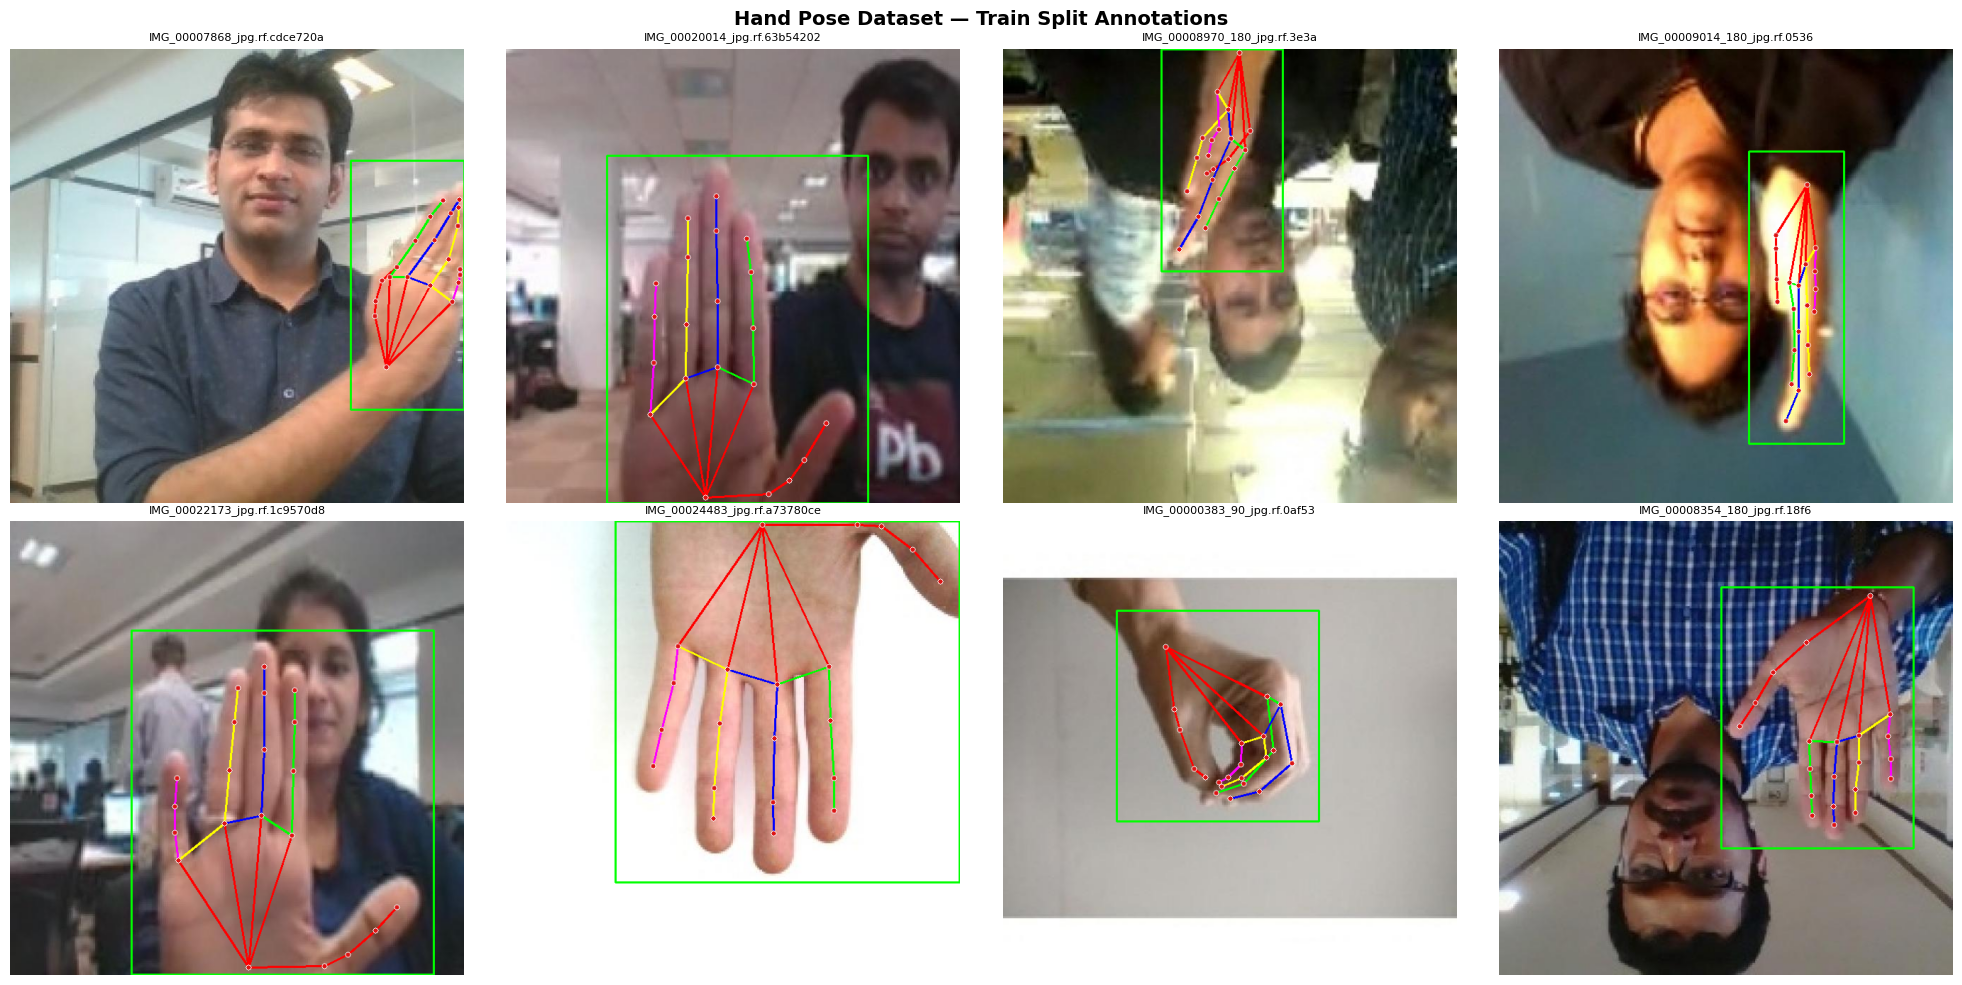

✅ Saved: /kaggle/working/hand_pose_samples.png


In [4]:
FINGER_COLORS = [
    (255,  0,  0),   # Thumb  — red
    (  0,255,  0),   # Index  — green
    (  0,  0,255),   # Middle — blue
    (255,255,  0),   # Ring   — yellow
    (255,  0,255),   # Pinky  — magenta
]

def visualize_pose_samples(root, split, n=8):
    """Draw GT annotations: bounding box, skeleton, and keypoints."""
    img_dir = os.path.join(root, split, "images")
    lbl_dir = os.path.join(root, split, "labels")
    lbls = glob.glob(os.path.join(lbl_dir, "*.txt"))
    random.seed(0)
    random.shuffle(lbls)
    samples = []
    for lp in lbls:
        base = os.path.splitext(os.path.basename(lp))[0]
        for ext in ('.jpg','.jpeg','.png'):
            ip = os.path.join(img_dir, base + ext)
            if os.path.exists(ip):
                with open(lp) as f:
                    lines = [x.strip() for x in f if x.strip()]
                if lines:
                    samples.append((ip, lines))
                break
        if len(samples) == n:
            break
    cols = min(4, len(samples))
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if rows == 1 and cols == 1: axes = np.array([[axes]])
    elif rows == 1: axes = np.array([axes])
    axes = axes.flatten()
    for idx, (ip, lines) in enumerate(samples):
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        for ln in lines:
            v = list(map(float, ln.split()))
            cx,cy,bw,bh = v[1:5]
            x1,y1 = int((cx-bw/2)*W), int((cy-bh/2)*H)
            x2,y2 = int((cx+bw/2)*W), int((cy+bh/2)*H)
            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
            kraw = v[5:]
            nk   = len(kraw)//3
            kpts = [(kraw[i*3]*W, kraw[i*3+1]*H, int(kraw[i*3+2])) for i in range(nk)]
            for si,sj in SKELETON:
                if si<nk and sj<nk and kpts[si][2]>0 and kpts[sj][2]>0:
                    fc = FINGER_COLORS[min(min(si,sj)//4, len(FINGER_COLORS)-1)]
                    cv2.line(img,(int(kpts[si][0]),int(kpts[si][1])),(int(kpts[sj][0]),int(kpts[sj][1])),fc,2)
            for kx,ky,kv in kpts:
                if kv>0:
                    cv2.circle(img,(int(kx),int(ky)),4,(220,20,20),-1)
                    cv2.circle(img,(int(kx),int(ky)),4,(255,255,255),1)
        axes[idx].imshow(img)
        axes[idx].set_title(os.path.basename(ip)[:28], fontsize=8)
        axes[idx].axis('off')
    for idx in range(len(samples), len(axes)): axes[idx].axis('off')
    plt.suptitle(f"Hand Pose Dataset — {split.capitalize()} Split Annotations",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(KAGGLE_OUTPUT, "hand_pose_samples.png")
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {out}")

visualize_pose_samples(PREPARED_ROOT, "train", n=8)

## 🏋️ Step 5 — YOLOv12s-Pose Model Training

### Training Configuration

| Parameter | Value | Justification |
|-----------|-------|---------------|
| **Architecture** | `yolo12s-pose.yaml` | Attention-based small variant |
| **Pretrained** | No | No YOLO12-pose weights exist → random init |
| **Optimizer** | AdamW | Recommended for attention-based models |
| **lr0** | 0.01 | Initial learning rate |
| **lrf** | 0.01 | Final LR ratio (cosine annealing to 0.0001) |
| **Epochs** | 50 | Sufficient for convergence on 2250 samples |
| **Image Size** | 640 | Matches dataset preprocessing |
| **Batch Size** | 16 | Fits T4 16GB; higher = more stable gradients |
| **Workers** | 4 | Kaggle CPU cores available |
| **Device** | 0 (CUDA GPU) | Kaggle T4/P100 |
| **Early Stopping** | patience=15 | Stop if no improvement for 15 epochs |

### Data Augmentation
| Augmentation | Value | Notes |
|-------------|-------|-------|
| Mosaic | 1.0 | Mix 4 images → richer context |
| Horizontal flip | 0.5 | flip_idx identity (no mirrored pairs) |
| Vertical flip | 0.0 | Disabled (unnatural for hands) |
| Pose loss gain | 12.0 | Higher weight for keypoint accuracy |
| Keypoint objectness | 1.0 | Standard kobj weight |

> **Note:** Training from random weights on ~2250 images is ambitious.  
> Expect moderate mAP — the training pipeline itself is the deliverable  
> for this assignment, not COCO-level accuracy.

In [5]:
from ultralytics import YOLO
import time

# ── Print model summary ──────────────────────────────────────────
model = YOLO("yolo12s-pose.yaml")
print(f"\n{'='*60}")
print(f"  Model:         YOLOv12s-Pose")
print(f"  Architecture:  yolo12s-pose.yaml")
print(f"  Pretrained:    No (training from scratch)")
print(f"  Device:        {DEVICE}")
print(f"{'='*60}")
model.info(verbose=False)

# ── Train ────────────────────────────────────────────────────────
t0 = time.time()

results = model.train(
    data    = CUSTOM_YAML,
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,          # Kaggle T4 = 16 GB VRAM → batch 16 is safe
    device  = DEVICE,
    workers = 4,
    patience = 15,
    save    = True,
    save_period = 10,
    plots   = True,
    project = os.path.join(KAGGLE_OUTPUT, "runs", "pose"),
    name    = "yolo12s_hand",
    exist_ok = True,
    verbose  = True,
    # Augmentation
    mosaic  = 1.0,
    flipud  = 0.0,
    fliplr  = 0.5,
    # Loss weights
    pose    = 12.0,
    kobj    = 1.0,
)

elapsed = time.time() - t0
RESULTS_DIR    = os.path.join(KAGGLE_OUTPUT, "runs", "pose", "yolo12s_hand")
BEST_WEIGHTS   = os.path.join(RESULTS_DIR, "weights", "best.pt")
LAST_WEIGHTS   = os.path.join(RESULTS_DIR, "weights", "last.pt")

print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")
print(f"   Best weights:  {BEST_WEIGHTS}")
print(f"   Last weights:  {LAST_WEIGHTS}")
print(f"   Best exists:   {os.path.exists(BEST_WEIGHTS)}")


  Model:         YOLOv12s-Pose
  Architecture:  yolo12s-pose.yaml
  Pretrained:    No (training from scratch)
  Device:        0
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/hand_pose_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s-pose.yaml, momentum=0.93

## 📊 Step 6 — Explicit Model Evaluation & Training Metrics

### 6a — `model.val()` Evaluation
Running a clean validation pass after training to report:
- **Box mAP50 / mAP50-95** — bounding box detection accuracy
- **Pose mAP50 / mAP50-95** — keypoint localization accuracy (OKS metric)
- **Precision / Recall** — per-class detection confidence

### 6b — Training Curves
- All **loss curves** (box, pose, kobj, cls, dfl) — train & val per epoch
- All **metric curves** (mAP50, mAP50-95, precision, recall)

In [6]:
import pandas as pd

# ── 6a: Load best weights & run validation ───────────────────────
weight_path = BEST_WEIGHTS if os.path.exists(BEST_WEIGHTS) else LAST_WEIGHTS

if os.path.exists(weight_path):
    trained_model = YOLO(weight_path)
    print(f"✅ Loaded: {weight_path}")

    print(f"\n{'='*60}")
    print(f"  Running model.val() on validation split")
    print(f"{'='*60}")
    val_res = trained_model.val(
        data   = CUSTOM_YAML,
        device = DEVICE,
        batch  = 16,
        imgsz  = 640,
        plots  = True,
        save_json = False,
        project = os.path.join(KAGGLE_OUTPUT, "runs", "val"),
        name    = "yolo12s_hand_val",
        exist_ok = True,
    )

    print(f"\n{'='*50}")
    print(f"  📊 Final Evaluation Metrics")
    print(f"{'='*50}")
    print(f"  Box  mAP@0.50:      {val_res.box.map50:.4f}")
    print(f"  Box  mAP@0.50:0.95: {val_res.box.map:.4f}")
    print(f"  Pose mAP@0.50:      {val_res.pose.map50:.4f}")
    print(f"  Pose mAP@0.50:0.95: {val_res.pose.map:.4f}")
    print(f"  Precision:          {val_res.box.mp:.4f}")
    print(f"  Recall:             {val_res.box.mr:.4f}")
    print(f"{'='*50}")
else:
    print("⚠️ No weights found. Run Step 5 first.")

✅ Loaded: /kaggle/working/runs/pose/yolo12s_hand/weights/best.pt

  Running model.val() on validation split
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO12s-pose summary (fused): 168 layers, 9,858,936 parameters, 0 gradients, 23.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 961.2±387.0 MB/s, size: 29.2 KB)
val: Scanning /kaggle/working/Hand_Prepared/val/labels.cache... 250 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 80.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.8it/s 5.7s
                   all        250        250      0.958      0.924      0.963      0.704      0.399      0.244      0.211     0.0375
Speed: 1.8ms preprocess, 14.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/val/yolo12s_hand_val

  📊 Final Evaluation Metrics
  Box  mAP@0.50:  

Epochs trained: 50


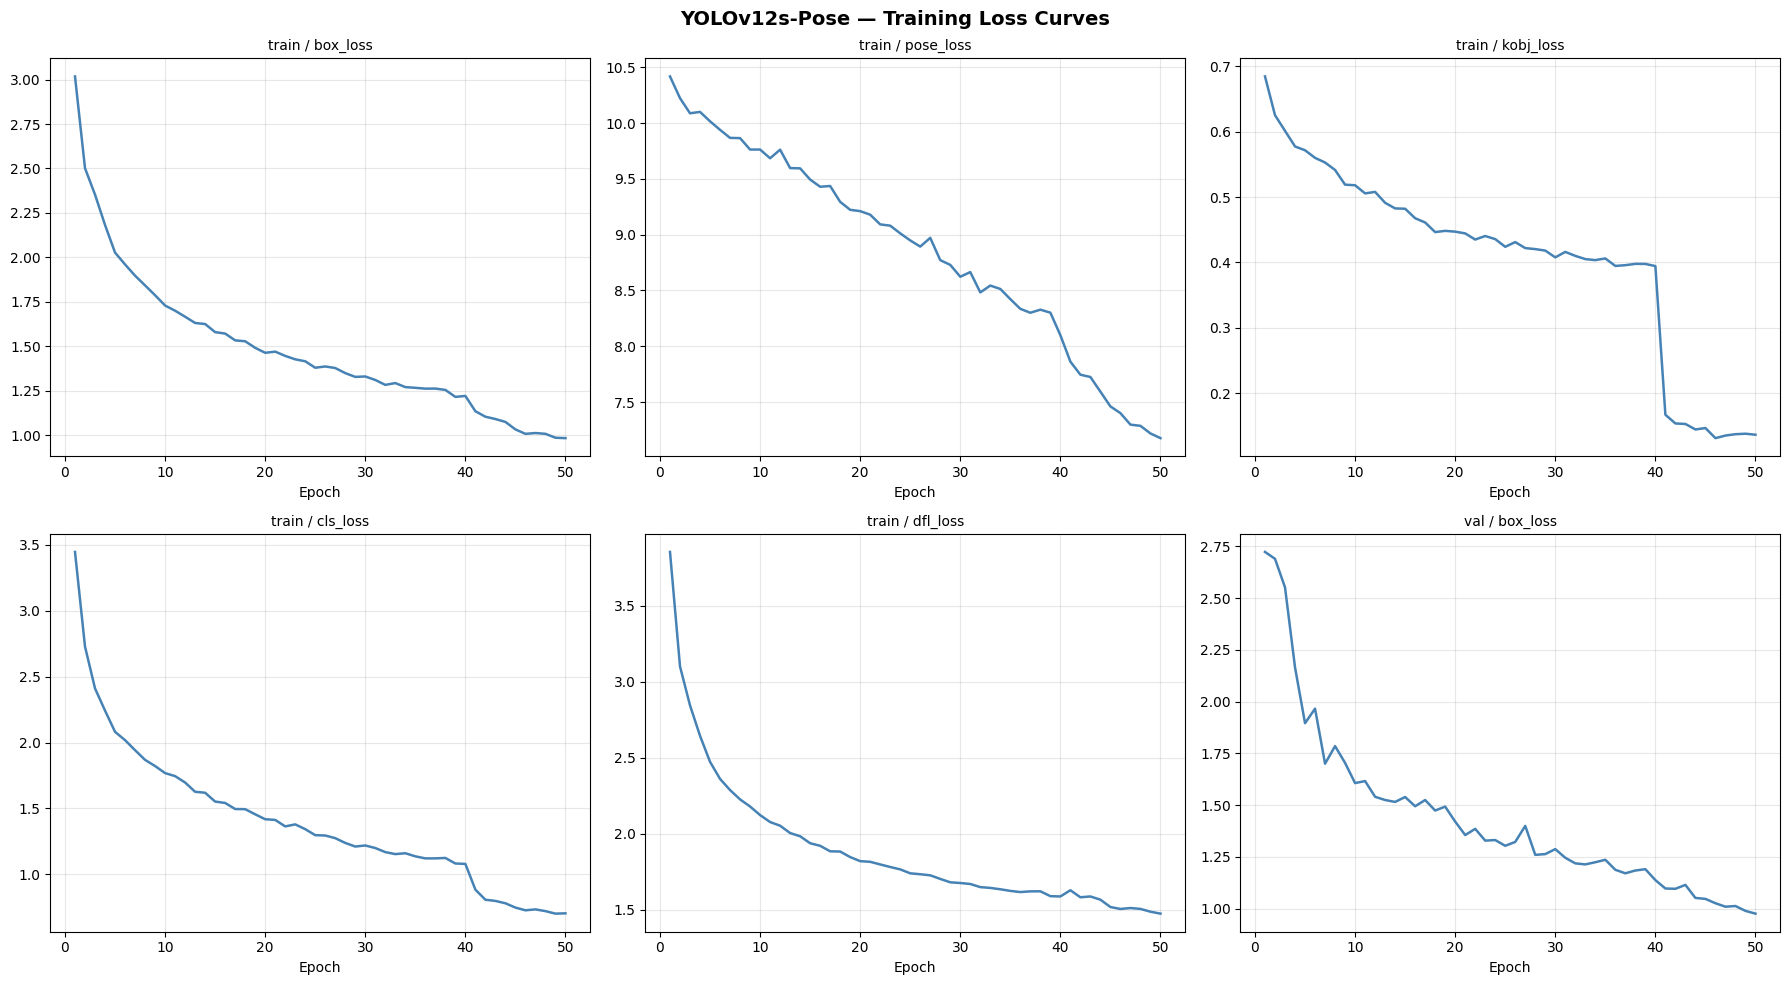

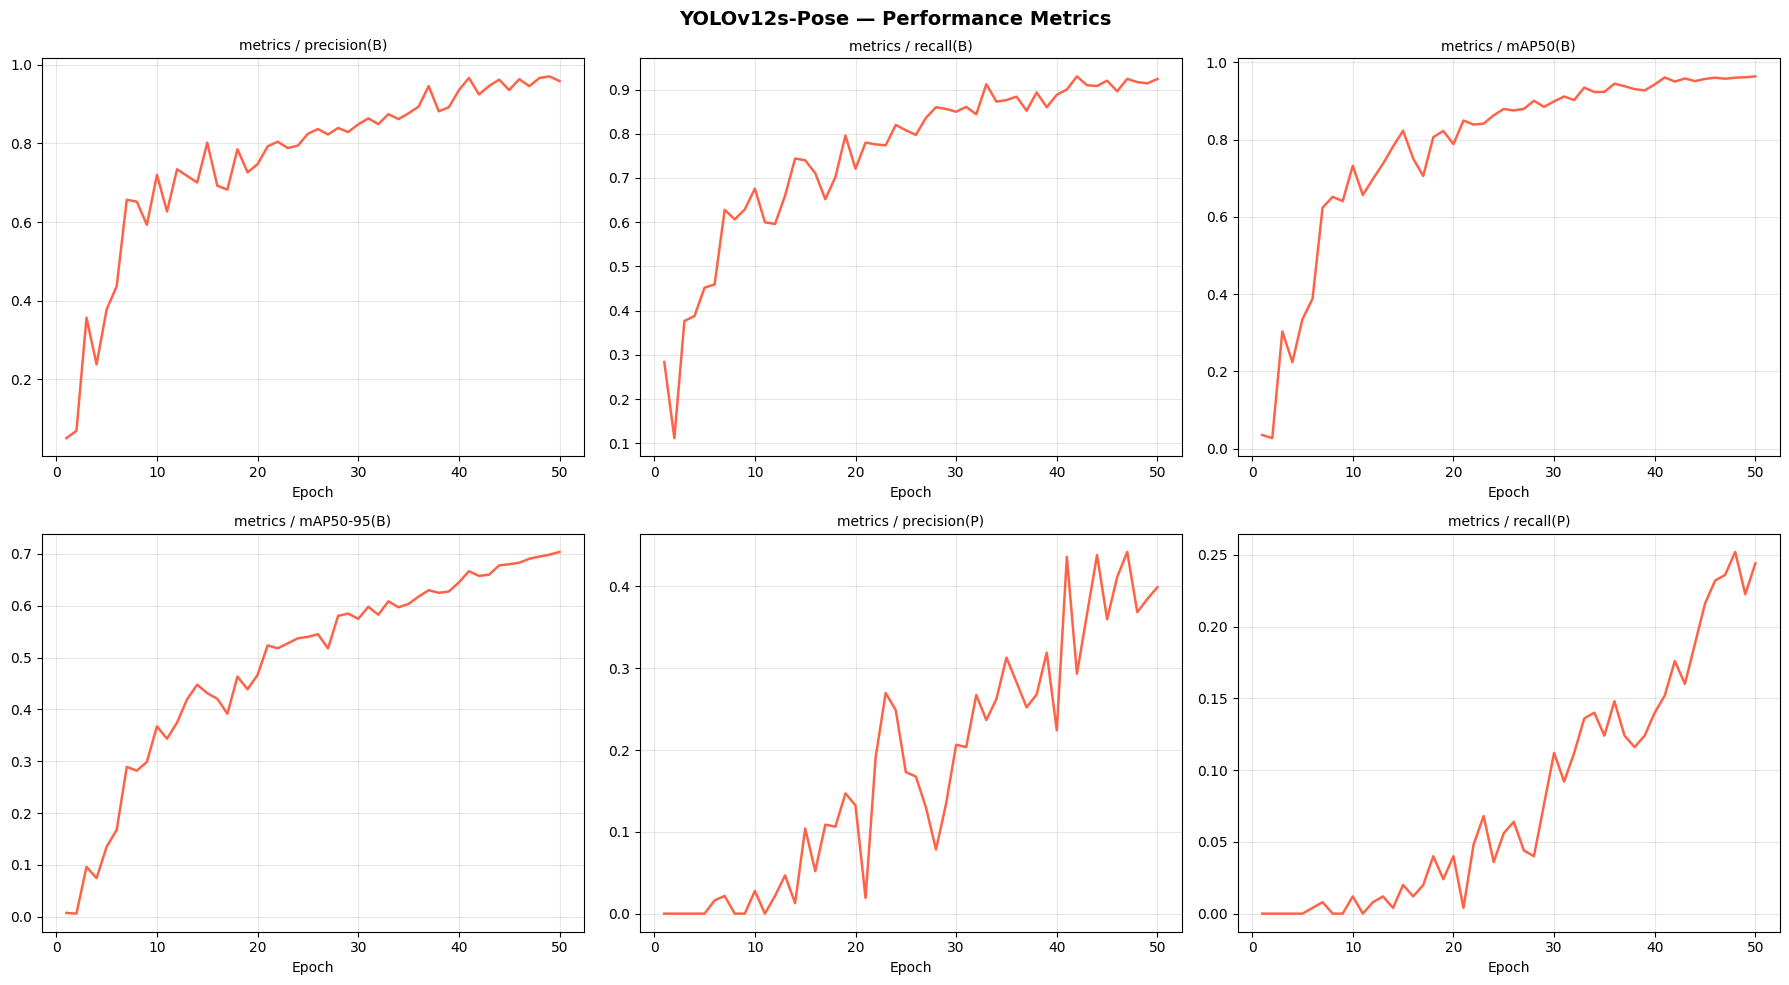

✅ Plots saved to /kaggle/working/


In [7]:
# ── 6b: Training curve plots ─────────────────────────────────────
csv_path = os.path.join(RESULTS_DIR, "results.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print(f"Epochs trained: {len(df)}")

    # ── Loss curves ──────────────────────────────────────────────
    loss_cols = [c for c in df.columns if 'loss' in c.lower()]
    if loss_cols:
        n = min(len(loss_cols), 6)
        fig, axs = plt.subplots(2, 3, figsize=(18, 10))
        axs = axs.flatten()
        for i, col in enumerate(loss_cols[:n]):
            axs[i].plot(df['epoch'], df[col], linewidth=1.8, color='steelblue')
            axs[i].set_title(col.replace('/', ' / '), fontsize=10)
            axs[i].set_xlabel('Epoch')
            axs[i].grid(True, alpha=0.3)
        for i in range(n, 6): axs[i].axis('off')
        plt.suptitle("YOLOv12s-Pose — Training Loss Curves", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(KAGGLE_OUTPUT, "training_loss_curves.png"), dpi=150)
        plt.show()

    # ── Metric curves ─────────────────────────────────────────────
    metric_cols = [c for c in df.columns
                   if any(k in c.lower() for k in ('map','precision','recall'))]
    if metric_cols:
        n = min(len(metric_cols), 6)
        fig, axs = plt.subplots(2, 3, figsize=(18, 10))
        axs = axs.flatten()
        for i, col in enumerate(metric_cols[:n]):
            axs[i].plot(df['epoch'], df[col], linewidth=1.8, color='tomato')
            axs[i].set_title(col.replace('/', ' / '), fontsize=10)
            axs[i].set_xlabel('Epoch')
            axs[i].grid(True, alpha=0.3)
        for i in range(n, 6): axs[i].axis('off')
        plt.suptitle("YOLOv12s-Pose — Performance Metrics", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(KAGGLE_OUTPUT, "training_metrics_curves.png"), dpi=150)
        plt.show()

    print("✅ Plots saved to /kaggle/working/")
else:
    print(f"⚠️ results.csv not found at {csv_path}")

## 🔍 Step 7 — Pose Estimation Inference on Held-Out Validation Images

Running the trained model on **validation images** that were never seen during training:
- Bounding boxes with confidence scores
- 21-keypoint skeleton overlay
- Qualitative assessment of keypoint localization accuracy

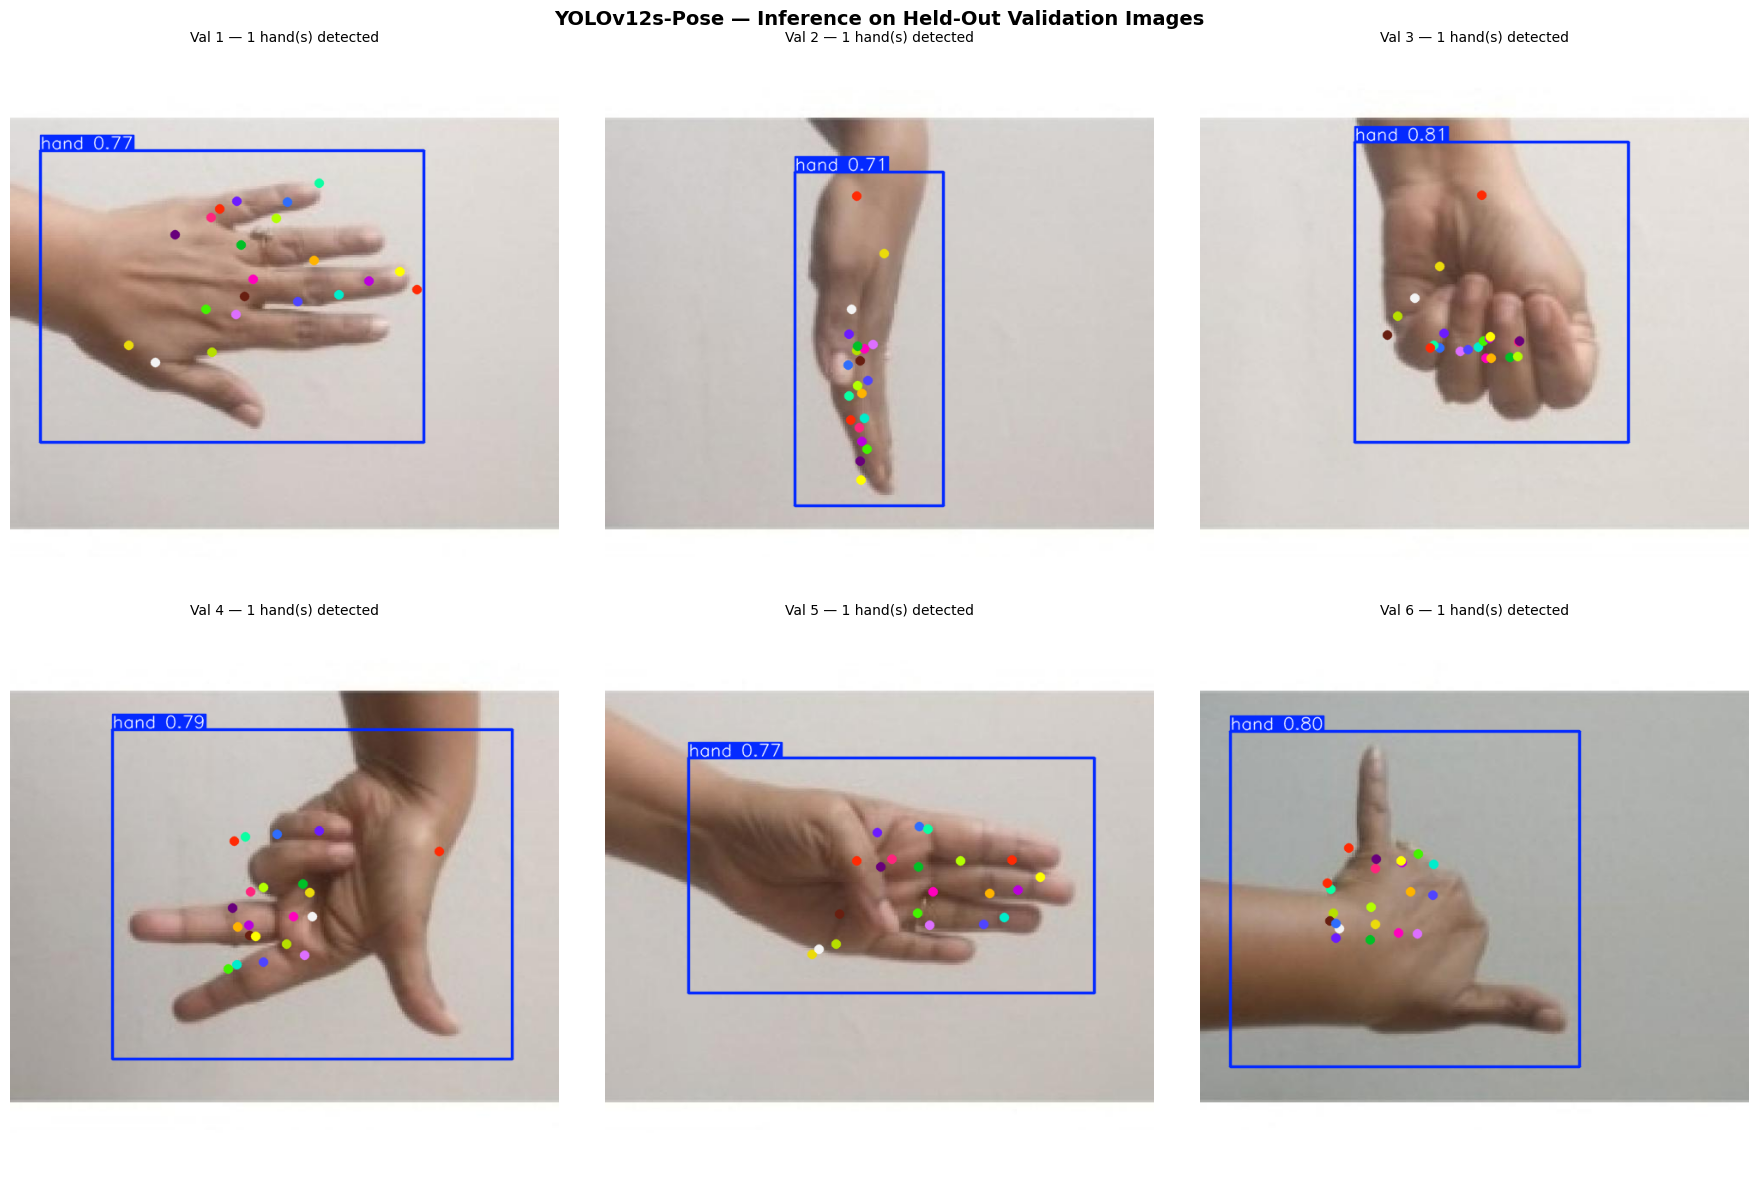

✅ Saved: /kaggle/working/inference_results.png


In [8]:
if os.path.exists(weight_path):
    val_img_dir = os.path.join(PREPARED_ROOT, "val", "images")
    val_imgs    = sorted(glob.glob(os.path.join(val_img_dir, "*.jpg")))[:6]
    if not val_imgs:
        val_imgs = sorted(glob.glob(os.path.join(val_img_dir, "*.png")))[:6]

    if val_imgs:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        axs = axs.flatten()
        for i, img_path in enumerate(val_imgs):
            res       = trained_model(img_path, verbose=False, device=DEVICE)
            annotated = cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)
            n_hands   = len(res[0].boxes) if res[0].boxes is not None else 0
            axs[i].imshow(annotated)
            axs[i].set_title(f"Val {i+1} — {n_hands} hand(s) detected", fontsize=10)
            axs[i].axis('off')
        for i in range(len(val_imgs), 6): axs[i].axis('off')
        plt.suptitle("YOLOv12s-Pose — Inference on Held-Out Validation Images",
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        out = os.path.join(KAGGLE_OUTPUT, "inference_results.png")
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {out}")
    else:
        print("⚠️ No validation images found.")
else:
    print("⚠️ No trained model found. Run Step 5 first.")

## 💾 Step 8 — Export Trained Weights

The trained `best.pt` weights are saved to `/kaggle/working/runs/pose/yolo12s_hand/weights/best.pt`.

To use them in the **video tracking notebook**:
1. Download `best.pt` from Kaggle's output panel
2. Upload it to the video tracking notebook as a dataset or file
3. Set `MODEL_PATH = "/kaggle/input/<your-model-dataset>/best.pt"` in the tracking notebook

In [9]:
import shutil

# ── Copy best.pt to output root for easy download ────────────────
export_dst = os.path.join(KAGGLE_OUTPUT, "yolo12s_hand_best.pt")
if os.path.exists(BEST_WEIGHTS):
    shutil.copy2(BEST_WEIGHTS, export_dst)
    size_mb = os.path.getsize(export_dst) / 1e6
    print(f"✅ Weights exported: {export_dst} ({size_mb:.1f} MB)")
elif os.path.exists(LAST_WEIGHTS):
    shutil.copy2(LAST_WEIGHTS, export_dst)
    size_mb = os.path.getsize(export_dst) / 1e6
    print(f"✅ Last weights exported (no best.pt): {export_dst} ({size_mb:.1f} MB)")
else:
    print("⚠️ No weights to export. Run training first.")

# ── List all outputs ─────────────────────────────────────────────
print(f"\n📂 /kaggle/working/ contents:")
for item in sorted(os.listdir(KAGGLE_OUTPUT)):
    full = os.path.join(KAGGLE_OUTPUT, item)
    if os.path.isfile(full):
        print(f"  {item:40s} {os.path.getsize(full)/1e6:.2f} MB")
    else:
        print(f"  {item}/")

print(f"\n⬇️  Download '{os.path.basename(export_dst)}' from the Output panel.")
print( "   Use it in the video tracking notebook to run ByteTrack & BoT-SORT.")

✅ Weights exported: /kaggle/working/yolo12s_hand_best.pt (20.2 MB)

📂 /kaggle/working/ contents:
  Hand_Prepared/
  __notebook__.ipynb                       5.75 MB
  hand_pose_data.yaml                      0.00 MB
  hand_pose_samples.png                    2.92 MB
  inference_results.png                    1.18 MB
  runs/
  training_loss_curves.png                 0.20 MB
  training_metrics_curves.png              0.22 MB
  yolo12s_hand_best.pt                     20.21 MB
  yolo26n.pt                               5.54 MB

⬇️  Download 'yolo12s_hand_best.pt' from the Output panel.
   Use it in the video tracking notebook to run ByteTrack & BoT-SORT.
